### **We use the prtrained model for glacier mapping**


In [4]:
import torch
import numpy as np
import rasterio as rio
import pandas as pd
from glob import glob
from model import unet
from pyrsimg import imsShow
from notebooks import config
from pyrsimg import img2patch
from utils.metrics import metrics_segm


In [18]:
dir_val_scene = 'data/dset/val/scene' 
dir_val_truth = 'data/dset/val/truth' 
paths_val_scene = sorted(glob(dir_val_scene+'/*'))
paths_val_truth = sorted(glob(dir_val_truth+'/*'))


In [19]:
## load trained model
path_trained_model = 'model/trained/unet_09304.pth'
model = unet(num_bands=6)
model.load_state_dict(torch.load(path_trained_model, weights_only=True))
model.eval();  ##  



In [36]:
## data prepare: choose one scene for inference
print(len(paths_val_scene))  
# id = np.random.randint(0, len(paths_val_scene))
id = 23
path_scene = paths_val_scene[id]
path_truth = paths_val_truth[id]
print('scene path:', path_scene)


43
scene path: data/dset/val/scene/l5_scene_21.tif


In [37]:
with rio.open(path_truth) as truth_rio:
    truth_arr = truth_rio.read(1)  # (H,W)
    profile_truth = truth_rio.profile
with rio.open(path_scene) as scene_rio:
    scene_arr = scene_rio.read()
    scene_arr = scene_arr.transpose((1, 2, 0))  # (H,W,C)
scene_arr.shape



(1116, 1215, 6)

In [38]:
def model_infer(scene_arr, model):
    ### image to patches
    imgPat_obj = img2patch(img=scene_arr, patch_size=512, edge_overlay = 40)
    patch_arr_list = imgPat_obj.toPatch()
    # channel first and numpy array to torch tensor
    patch_list = [torch.from_numpy(patch.transpose(2,0,1)).float() for patch in patch_arr_list]  
    with torch.no_grad():  ## save 
        presult_list = [model(patch[np.newaxis, :]) for patch in patch_list]
    ## channel last and torch tensor to numpy array
    presult_arr_list = [np.squeeze(patch.detach().numpy().transpose(0,2,3,1), axis = 0) 
                                    for patch in presult_list ]       
    ## patch to image
    gla_pred_prob = imgPat_obj.toImage(presult_arr_list)
    gla_pred_cla = np.where(gla_pred_prob>0.5, 1, 0) 
    gla_pred_cla = gla_pred_cla.squeeze().astype(np.uint8) 
    
    return gla_pred_cla

wat_pred_cla = model_infer(scene_arr=scene_arr, model=model) 




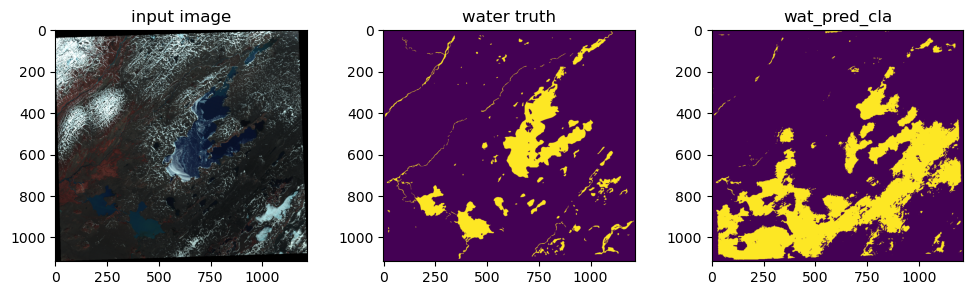

In [43]:
### show the results
imsShow([scene_arr, truth_arr, wat_pred_cla], 
        clip_list=[2, 2, 0], 
        color_bands_list = [[3,2,1], [0,0,0], [0,0,0]],
        img_name_list = ['input image', 'water truth', 'wat_pred_cla'],
        figsize=(12, 3));


In [44]:
metrics_sg = metrics_segm(cla_map=wat_pred_cla, 
                          truth_map=truth_arr, 
                          class_labels=[0, 1],
                          mean_mode=True)
metrics_gla = {'oa': metrics_sg.oa,
               'dice_mean': metrics_sg.dice['labels_mean'],
               'miou': metrics_sg.iou['labels_mean']}
metrics_gla



{'oa': np.float64(0.7933802380636311),
 'dice_mean': np.float64(0.6355822732719716),
 'miou': np.float64(0.5125480981560471)}

In [31]:
metrics_scenes = {}
for path_scene, path_truth in zip(paths_val_scene, paths_val_truth):
    print('scene path:', path_scene)
    with rio.open(path_truth) as truth_rio:
        truth_arr = truth_rio.read(1)  # (H,W)
        profile_truth = truth_rio.profile
    with rio.open(path_scene) as scene_rio:
        scene_arr = scene_rio.read().transpose((1, 2, 0))  # (H,W,C)
    wat_pred_cla = model_infer(scene_arr=scene_arr, model=model) 
    metrics_sg = metrics_segm(cla_map=wat_pred_cla, truth_map=truth_arr, 
                              class_labels=[0, 1], mean_mode=True)
    metrics = {'oa': metrics_sg.oa,
                   'dice_mean': metrics_sg.dice['labels_mean'],
                   'miou': metrics_sg.iou['labels_mean']}
    metrics_scenes[path_scene.split('/')[-1].split('.')[0]] = metrics


scene path: data/dset/val/scene/S2A_L2A_20190125_N0211_R034_S1.tif
scene path: data/dset/val/scene/S2A_L2A_20190206_N0211_R067_S3.tif
scene path: data/dset/val/scene/S2A_L2A_20190318_N0211_R061_S2.tif
scene path: data/dset/val/scene/S2A_L2A_20190429_N0211_R096_S1.tif
scene path: data/dset/val/scene/S2A_L2A_20190508_N0212_R078_S3.tif
scene path: data/dset/val/scene/S2A_L2A_20190716_N0213_R063_S2.tif
scene path: data/dset/val/scene/S2A_L2A_20190725_N0213_R054_S1.tif
scene path: data/dset/val/scene/S2A_L2A_20190811_N0213_R013_S2.tif
scene path: data/dset/val/scene/S2A_L2A_20190817_N0213_R089_S4.tif
scene path: data/dset/val/scene/S2B_L2A_20181226_N0211_R102_S2.tif
scene path: data/dset/val/scene/S2B_L2A_20190303_N0211_R065_S1.tif
scene path: data/dset/val/scene/S2B_L2A_20190430_N0211_R035_S3.tif
scene path: data/dset/val/scene/S2B_L2A_20190607_N0212_R012_S2.tif
scene path: data/dset/val/scene/S2B_L2A_20190620_N0212_R053_S1.tif
scene path: data/dset/val/scene/S2B_L2A_20190801_N0213_R084_S3

In [32]:
df_metrics_scenes = pd.DataFrame.from_dict(metrics_scenes, orient='index')
df_metrics_scenes
# df_metrics_scenes.mean()



,oa,dice_mean,miou
S2A_L2A_20190125_N0211_R034_S1,0.966281,0.960096,0.923694
S2A_L2A_20190206_N0211_R067_S3,0.968819,0.897690,0.825303
S2A_L2A_20190318_N0211_R061_S2,0.982845,0.930986,0.876760
S2A_L2A_20190429_N0211_R096_S1,0.983723,0.969804,0.942147
S2A_L2A_20190508_N0212_R078_S3,0.988751,0.955680,0.917699
S2A_L2A_20190716_N0213_R063_S2,0.967211,0.930346,0.873970
S2A_L2A_20190725_N0213_R054_S1,0.996379,0.995115,0.990289
S2A_L2A_20190811_N0213_R013_S2,0.986656,0.974872,0.951525
S2A_L2A_20190817_N0213_R089_S4,0.957542,0.775127,0.678721
S2B_L2A_20181226_N0211_R102_S2,0.980174,0.978884,0.958693


### write out prediction map

In [ ]:
# # ### write the result to path
# path_wat_pred_cla = config.dir_result + scene_id + '_pred_cla.tif'   ## path to save result
# with rio.open(path_wat_pred_cla, 'w', **profile_truth) as dst:
#     dst.write(wat_pred_cla[:,:,0], 1)  # write to the first band


In [10]:
# ## load and show the image and the prediction map
# with rio.open(path_scene) as img_src, rio.open(path_gla_pred_cla) as pred_src, rio.open(path_dem) as dem_src:
#         scene_arr = img_src.read().transpose(1, 2, 0)  # change to channel last format
#         dem_arr = dem_src.read(1)
#         pred_arr = pred_src.read(1)   # read the first band (the classification result)
# imsShow([scene_arr, dem_arr, pred_arr], 
#         ['input image', 'dem', 'glacier prediction'], 
#         clip_list=[2, 2, 2], 
#         figsize=(10, 3))



Vector saved to l7_scene_wat_cla.gpkg, Feature count: 26


Warning 1: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
